In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


(a)Downloading

In [2]:
import pandas as pd
import os

def load_instance(filepath):
    df = pd.read_csv(filepath, comment='#', header=None,
                      names=['time','avg_rss12','var_rss12','avg_rss13',
                             'var_rss13','avg_rss23','var_rss23'])
    return df.drop(columns='time')

(b)Train/Test

In [6]:
folders = ['bending1','bending2','cycling','lying','sitting','standing','walking']
base_path = '/content/drive/MyDrive/USC_Summer26/EE559/Data/AReM'

train_files, test_files = [], []

for folder in folders:
    folder_path = os.path.join(base_path, folder)
    files = sorted(os.listdir(folder_path))
    for f in files:
        idx = int(''.join(filter(str.isdigit, f)))
        full_path = os.path.join(folder_path, f)
        if folder in ['bending1','bending2']:
            if idx in [1,2]:
                test_files.append((full_path, folder))
            else:
                train_files.append((full_path, folder))
        else:
            if idx in [1,2,3]:
                test_files.append((full_path, folder))
            else:
                train_files.append((full_path, folder))

(c)i_time-domian

Including min, max, mean, median, std, Q1, Q3 (7 features * 6 time series = 42 features per instance)

(c)ii_feature extraction

In [9]:
def find_bad_files(file_list):
    bad_files = []
    for path, label in file_list:
        try:
            pd.read_csv(path, comment='#', header=None)
        except Exception as e:
            print(f"❌ {path}\n   {e}\n")
            bad_files.append(path)
    return bad_files

bad_train = find_bad_files(train_files)
bad_test  = find_bad_files(test_files)
print("Total bad files:", len(bad_train) + len(bad_test))

❌ /content/drive/MyDrive/USC_Summer26/EE559/Data/AReM/cycling/dataset14.csv
   Error tokenizing data. C error: Expected 7 fields in line 485, saw 8


❌ /content/drive/MyDrive/USC_Summer26/EE559/Data/AReM/cycling/dataset9.csv
   Error tokenizing data. C error: Expected 7 fields in line 485, saw 8


Total bad files: 2


In [12]:
def load_instance(filepath):
    """Load a single AReM CSV file, robust to minor formatting errors like trailing commas."""
    try:
        df = pd.read_csv(filepath, comment='#', header=None,
                          names=['time','avg_rss12','var_rss12','avg_rss13',
                                 'var_rss13','avg_rss23','var_rss23'])
    except pd.errors.ParserError:
        with open(filepath) as f:
            raw_lines = f.readlines()
        cleaned_lines = [line.rstrip('\n').rstrip(',') + '\n'
                          for line in raw_lines if not line.startswith('#')]
        from io import StringIO
        df = pd.read_csv(StringIO(''.join(cleaned_lines)), header=None,
                          names=['time','avg_rss12','var_rss12','avg_rss13',
                                 'var_rss13','avg_rss23','var_rss23'])
        print(f"⚠️  Cleaned trailing comma issue in: {filepath}")

    df = df.drop(columns='time')
    df = df.apply(pd.to_numeric, errors='coerce')
    df = df.dropna(how='all')
    return df

In [13]:
import numpy as np

def extract_features(df):
    feats = {}
    for col in df.columns:
        s = df[col]
        feats[f'min_{col}']    = s.min()
        feats[f'max_{col}']    = s.max()
        feats[f'mean_{col}']   = s.mean()
        feats[f'median_{col}'] = s.median()
        feats[f'std_{col}']    = s.std()
        feats[f'q1_{col}']     = s.quantile(0.25)
        feats[f'q3_{col}']     = s.quantile(0.75)
    return feats

def build_dataset(file_list):
    rows = []
    for path, label in file_list:
        df = load_instance(path)
        feats = extract_features(df)
        feats['label'] = label
        rows.append(feats)
    return pd.DataFrame(rows)

train_df = build_dataset(train_files)
test_df  = build_dataset(test_files)

⚠️  Cleaned trailing comma issue in: /content/drive/MyDrive/USC_Summer26/EE559/Data/AReM/cycling/dataset14.csv
⚠️  Cleaned trailing comma issue in: /content/drive/MyDrive/USC_Summer26/EE559/Data/AReM/cycling/dataset9.csv


In [14]:
print("train_df shape:", train_df.shape)
print("test_df shape:", test_df.shape)
print("\ntrain_df columns:", list(train_df.columns))
print("\n", train_df.head())

train_df shape: (69, 43)
test_df shape: (19, 43)

train_df columns: ['min_avg_rss12', 'max_avg_rss12', 'mean_avg_rss12', 'median_avg_rss12', 'std_avg_rss12', 'q1_avg_rss12', 'q3_avg_rss12', 'min_var_rss12', 'max_var_rss12', 'mean_var_rss12', 'median_var_rss12', 'std_var_rss12', 'q1_var_rss12', 'q3_var_rss12', 'min_avg_rss13', 'max_avg_rss13', 'mean_avg_rss13', 'median_avg_rss13', 'std_avg_rss13', 'q1_avg_rss13', 'q3_avg_rss13', 'min_var_rss13', 'max_var_rss13', 'mean_var_rss13', 'median_var_rss13', 'std_var_rss13', 'q1_var_rss13', 'q3_var_rss13', 'min_avg_rss23', 'max_avg_rss23', 'mean_avg_rss23', 'median_avg_rss23', 'std_avg_rss23', 'q1_avg_rss23', 'q3_avg_rss23', 'min_var_rss23', 'max_var_rss23', 'mean_var_rss23', 'median_var_rss23', 'std_var_rss23', 'q1_var_rss23', 'q3_var_rss23', 'label']

    min_avg_rss12  max_avg_rss12  mean_avg_rss12  median_avg_rss12  \
0          35.00          47.40       43.954500             44.33   
1          33.00          47.75       42.179812         

In [18]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
print(train_df.head())

   min_avg_rss12  max_avg_rss12  mean_avg_rss12  median_avg_rss12  \
0          35.00          47.40       43.954500             44.33   
1          33.00          47.75       42.179812             43.50   
2          33.00          45.75       41.678063             41.75   
3          37.00          48.00       43.454958             43.25   
4          36.25          48.00       43.969125             44.50   

   std_avg_rss12  q1_avg_rss12  q3_avg_rss12  min_var_rss12  max_var_rss12  \
0       1.558835         43.00         45.00            0.0           1.70   
1       3.670666         39.15         45.00            0.0           3.00   
2       2.243490         41.33         42.75            0.0           2.83   
3       1.386098         42.50         45.00            0.0           1.58   
4       1.618364         43.31         44.67            0.0           1.50   

   mean_var_rss12  median_var_rss12  std_var_rss12  q1_var_rss12  \
0        0.426250              0.47       0.3386

(c)iii_Bootstrap Confidence

In [15]:
def bootstrap_std_ci(data, n_boot=2000, ci=0.90, seed=42):
    rng = np.random.default_rng(seed)
    n = len(data)
    boot_stds = np.empty(n_boot)
    for b in range(n_boot):
        sample = rng.choice(data, size=n, replace=True)
        boot_stds[b] = np.std(sample, ddof=1)
    alpha = 1 - ci
    lower = np.percentile(boot_stds, 100 * alpha / 2)
    upper = np.percentile(boot_stds, 100 * (1 - alpha / 2))
    return np.std(data, ddof=1), lower, upper

feature_cols = [c for c in train_df.columns if c != 'label']

results = {}
for col in feature_cols:
    point_est, lo, hi = bootstrap_std_ci(train_df[col].dropna().values)
    results[col] = {'std': point_est, 'ci_lower': lo, 'ci_upper': hi}

ci_df = pd.DataFrame(results).T
ci_df

,std,ci_lower,ci_upper
min_avg_rss12,8.856393,7.574345,10.131098
max_avg_rss12,4.192017,3.013055,5.161329
mean_avg_rss12,4.825378,4.245164,5.317102
median_avg_rss12,4.872952,4.228238,5.406119
std_avg_rss12,1.757124,1.539868,1.931470
q1_avg_rss12,5.690096,5.115897,6.164178
q3_avg_rss12,4.622275,3.782399,5.347850
min_var_rss12,0.000000,0.000000,0.000000
max_var_rss12,5.144249,4.642560,5.519378
mean_var_rss12,1.605163,1.404737,1.742548


(c)iv_Select_Three

In [16]:
train_df['is_bending'] = train_df['label'].isin(['bending1', 'bending2'])

separation_scores = {}
for col in feature_cols:
    bend_mean = train_df.loc[train_df['is_bending'], col].mean()
    other_mean = train_df.loc[~train_df['is_bending'], col].mean()
    pooled_std = train_df[col].std()
    separation_scores[col] = abs(bend_mean - other_mean) / pooled_std

sep_series = pd.Series(separation_scores).sort_values(ascending=False)
print(sep_series.head(10))

max_avg_rss23       2.486616
mean_avg_rss23      1.984808
q3_avg_rss23        1.964749
median_avg_rss23    1.871148
q1_avg_rss23        1.816336
min_avg_rss23       1.749369
max_avg_rss13       1.452095
std_avg_rss13       1.143415
q3_avg_rss13        1.061238
q1_var_rss23        1.017711
dtype: float64


/tmp/ipykernel_9269/2556896239.py:8: RuntimeWarning: invalid value encountered in scalar divide
  separation_scores[col] = abs(bend_mean - other_mean) / pooled_std


Interpretation

(c)v_Scatter plots

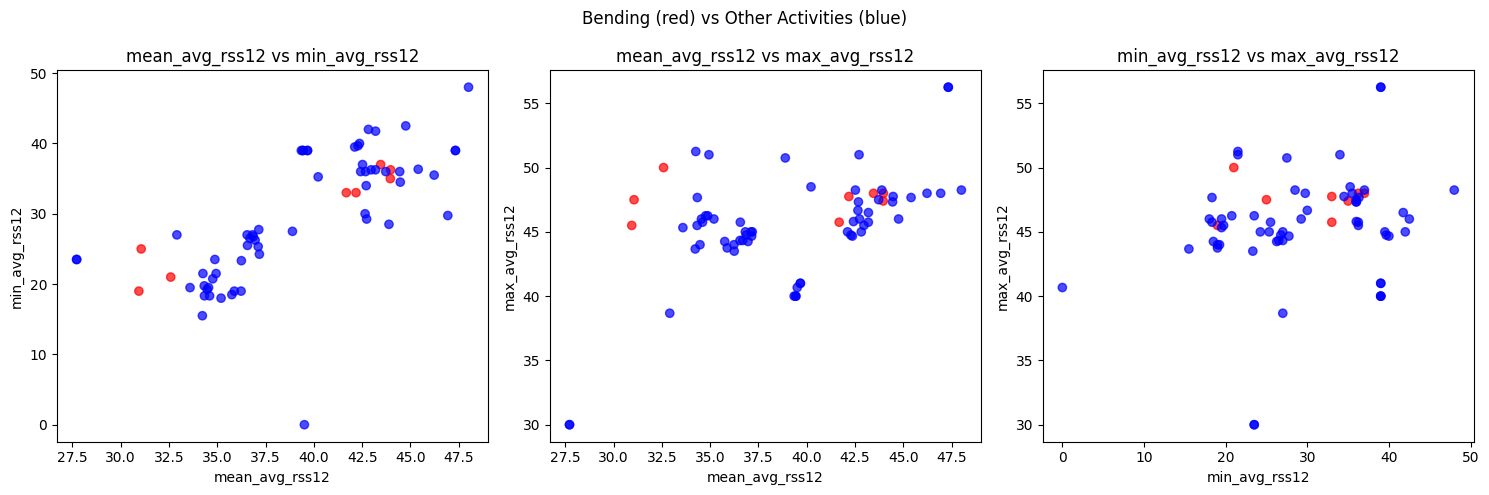

In [17]:
import matplotlib.pyplot as plt

selected_features = ['mean_avg_rss12', 'min_avg_rss12', 'max_avg_rss12']  # example choice

colors = train_df['is_bending'].map({True: 'red', False: 'blue'})

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
pairs = [
    (selected_features[0], selected_features[1]),
    (selected_features[0], selected_features[2]),
    (selected_features[1], selected_features[2]),
]

for ax, (fx, fy) in zip(axes, pairs):
    ax.scatter(train_df[fx], train_df[fy], c=colors, alpha=0.7)
    ax.set_xlabel(fx)
    ax.set_ylabel(fy)
    ax.set_title(f'{fx} vs {fy}')

plt.suptitle('Bending (red) vs Other Activities (blue)')
plt.tight_layout()
plt.show()